In [5]:
!unzip /content/archive.zip -d /content/

Archive:  /content/archive.zip
   creating: /content/archive/
   creating: /content/archive/dataset_new/
   creating: /content/archive/dataset_new/test/
   creating: /content/archive/dataset_new/test/Closed/
  inflating: /content/archive/dataset_new/test/Closed/_107.jpg  
  inflating: /content/archive/dataset_new/test/Closed/_115.jpg  
  inflating: /content/archive/dataset_new/test/Closed/_116.jpg  
  inflating: /content/archive/dataset_new/test/Closed/_120.jpg  
  inflating: /content/archive/dataset_new/test/Closed/_129.jpg  
  inflating: /content/archive/dataset_new/test/Closed/_130.jpg  
  inflating: /content/archive/dataset_new/test/Closed/_132.jpg  
  inflating: /content/archive/dataset_new/test/Closed/_137.jpg  
  inflating: /content/archive/dataset_new/test/Closed/_14.jpg  
  inflating: /content/archive/dataset_new/test/Closed/_148.jpg  
  inflating: /content/archive/dataset_new/test/Closed/_152.jpg  
  inflating: /content/archive/dataset_new/test/Closed/_159.jpg  
  inflating: 

In [6]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# 1. Định nghĩa đường dẫn và nhãn
DATA_DIR = "/content/archive/dataset_new/train"  # Kiểm tra lại chính xác đường dẫn thư mục sau khi giải nén
CATEGORIES = ["Closed", "Open", "yawn", "no_yawn"]
IMG_SIZE = 64

data = []
labels = []

# 2. Đọc ảnh và tiền xử lý
for category in CATEGORIES:
    path = os.path.join(DATA_DIR, category)
    class_num = CATEGORIES.index(category)

    if not os.path.exists(path):
        print(f"Không tìm thấy thư mục: {path}")
        continue

    for img in os.listdir(path):
        try:
            img_path = os.path.join(path, img)
            # Đọc ảnh dạng màu (RGB)
            img_array = cv2.imread(img_path)
            # Resize ảnh về kích thước 64x64
            resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))

            data.append(resized_array)
            labels.append(class_num)
        except Exception as e:
            pass

# 3. Chuẩn hóa dữ liệu đưa về khoảng [0, 1]
X = np.array(data, dtype="float32") / 255.0
y = np.array(labels)

# One-hot encode nhãn (4 lớp)
y = to_categorical(y, num_classes=4)

# 4. Chia tập dữ liệu: 80% Train, 20% Validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")

X_train shape: (1973, 64, 64, 3)
X_val shape: (494, 64, 64, 3)


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Khởi tạo mô hình tuần tự tự dựng (CNN)
model = models.Sequential([
    # Tầng tích chập 1 + Giảm chiều
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D((2, 2)),

    # Tầng tích chập 2 + Giảm chiều
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Tầng tích chập 3 + Giảm chiều
    layers.Conv2D(124, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Phẳng hóa dữ liệu để đưa vào các tầng Dense
    layers.Flatten(),

    # Tầng ẩn Dense kết hợp Dropout chống học vẹt
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),

    # Tầng đầu ra với 4 neurons ứng với 4 nhãn (Softmax phân loại đa lớp)
    layers.Dense(4, activation='softmax')
])

# 2. Biên dịch mô hình (Compile)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Xem trước cấu trúc mạng
model.summary()

# 3. Tiến hành huấn luyện (Train) trong 20 Epochs
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 124)    │        71,548 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 124)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4464)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       285,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 376,960 (1.44 MB)

 Trainable params: 376,960 (1.44 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.6280 - loss: 0.7694 - val_accuracy: 0.7794 - val_loss: 0.4336
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7699 - loss: 0.4647 - val_accuracy: 0.7874 - val_loss: 0.3665
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7866 - loss: 0.4334 - val_accuracy: 0.7976 - val_loss: 0.3752
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7978 - loss: 0.3774 - val_accuracy: 0.7976 - val_loss: 0.3427
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8104 - loss: 0.3668 - val_accuracy: 0.7955 - val_loss: 0.3668
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8018 - loss: 0.3524 - val_accuracy: 0.8077 - val_loss: 0.3166
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8196 - loss: 0.3358 - val_accuracy: 0.8198 - val_loss: 0.3208
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8206 - loss: 0.3235 - val_accuracy: 0.7794 - val_lo

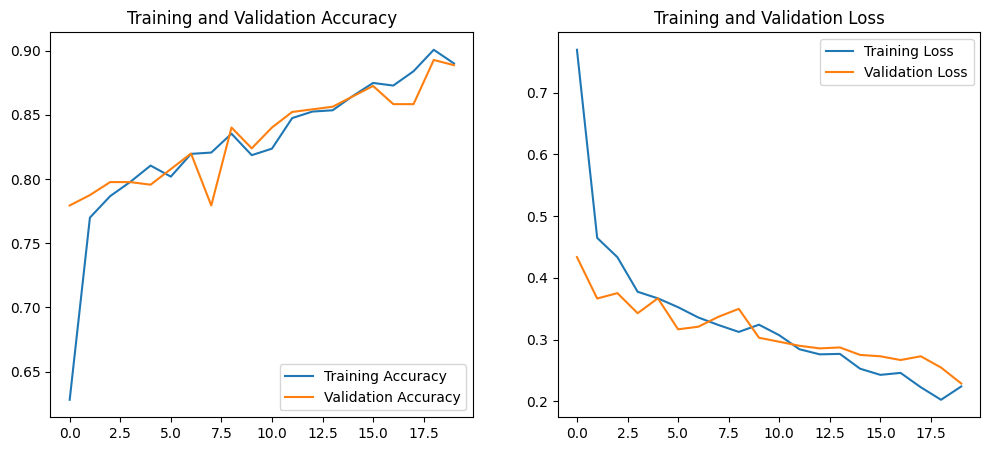

Đã xuất file bộ não thành công tại: models/drowsiness_model.h5


In [8]:
import matplotlib.pyplot as plt
import os

# 1. Vẽ biểu đồ Accuracy và Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

# 2. Tạo thư mục models và lưu file .h5
if not os.path.exists('models'):
    os.makedirs('models')

model.save('models/drowsiness_model.h5')
print("Đã xuất file bộ não thành công tại: models/drowsiness_model.h5")